# Assignment Instructions - Part 3: Parameter Estimation

This part builds directly on the previous section. Once we know how a model behaves under noise, we can ask a more realistic question: given a noisy dataset, what parameter values are most consistent with the observations?

The big idea is to treat this like a debugging task: test candidate parameters, compare output behavior, and decide which values best explain observed data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

import generate_dataset as gd

sp.init_printing()

## Start Here

We will do this in four small steps:

1. Generate one synthetic dataset with known truth metadata.
2. Run a brute-force search over candidate parameters.
3. Compare estimated parameters against truth.
4. Use the plot and error value to reason about trust in the estimated model.

In [3]:
# Generate one synthetic dataset
data, truth = gd.generate_dataset(
    model_name="exponential",
    seed=420,
    n_points=60,
    noise_fraction=0.10,
 )

display(data.head())
truth

,x,y
0,1.000000,47.936733
1,1.322034,42.233731
2,1.644068,37.003409
3,1.966102,31.454600
4,2.288136,27.297701


{'model_name': 'exponential',
 'parameters': {'A': 79.96840826135686, 'k': 0.47513005448377715},
 'seed': 420,
 'noise_fraction': 0.1,
 'n_points': 60}

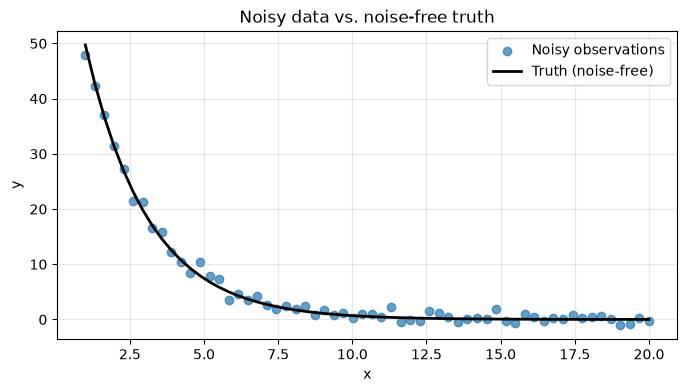

In [4]:
# Copied/adapted from the Part 2 figure-generation code
truth_data = gd.generate_truth_dataset(truth)

plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.plot(truth_data["x"], truth_data["y"], color="black", lw=2, label="Truth (noise-free)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy data vs. noise-free truth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Parameter Estimation Starter

This is a simple model-fitting workflow:

> define a model --> define an error metric --> search for the parameter pair that minimizes that error.

***TODO:*** Before running the search, discuss in your group which parameter (`P0` or `r`) you think will be harder to recover under noise, and why.

We will keep the mathematical theme consistent with SymPy by writing the model symbolically first and then converting it to a numerical function for the brute-force search. The point is not simply to get a number, but to inspect the error landscape and ask whether the fit makes physical sense.

**Group answer — which parameter is harder to recover, `P0` or `r`?**

`r` (the rate) is expected to be harder to recover than `P0` (the scale). `P0` mostly sets the vertical scale of the curve near `x` close to 0, while `r` controls how quickly the curve bends across the whole range. Because `P0` and `r` act together multiplicatively (`P0 * exp(-r*x)`), a slightly larger `P0` paired with a slightly larger `r` can trace nearly the same curve over the sampled `x`-range as a slightly smaller `P0` with a smaller `r`. This creates a "valley" of similarly good fits in (`P0`, `r`) space rather than one sharp minimum, so noise tends to push the recovered `r` around more than it pushes the recovered `P0`.

In [5]:
# 1. Observed data from the synthetic dataset
x_obs = data["x"].to_numpy()
y_obs = data["y"].to_numpy()

# 2. Symbolic model keeps the mathematics readable and in the SymPy theme
P0, r, x_sym = sp.symbols("P0 r x_sym", positive=True)
exp_symbolic = P0 * sp.exp(r * x_sym)
print("Symbolic model:") 
display(exp_symbolic)

# Convert the symbolic expression to a numerical function for the grid search
exp_model = sp.lambdify((x_sym, P0, r), exp_symbolic, "numpy")

# 3. Define the cost function to compare model output to data
#    We use mean squared error (MSE), which is a standard choice for noisy observations.
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

# 4. Search a finite grid of candidate parameters
p0_grid = np.linspace(0, 200, 120)
r_grid = np.linspace(0.001, 0.5, 120)

best = {"error": np.inf, "P0": None, "r": None}
for p0_val in p0_grid:
    for r_val in r_grid:
        y_pred = exp_model(x_obs, p0_val, r_val)
        err = mse(y_obs, y_pred)
        if err < best["error"]:
            best = {"error": err, "P0": float(p0_val), "r": float(r_val)}

print("Best fit on this grid:")
print(best)

Symbolic model:


Best fit on this grid:
{'error': 120.18662209932141, 'P0': 6.722689075630252, 'r': 0.001}


## Plot the results and see if the model looks right

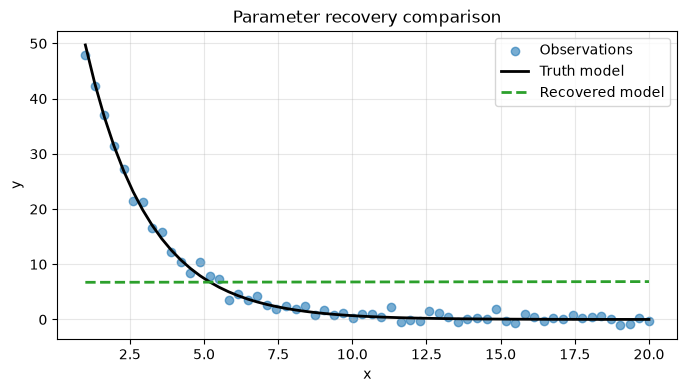

Recovered: {'P0': 6.722689075630252, 'r': 0.001}
Truth parameters: {'A': 79.96840826135686, 'k': 0.47513005448377715}
Best MSE: 120.18662209932141


Model with fitted parameters:


In [6]:
# Compare observations, best-fit model, and truth
best_curve = exp_model(x_obs, best["P0"], best["r"])
truth_curve = gd.evaluate_truth(x_obs, truth)

plt.figure(figsize=(8, 4))
plt.scatter(x_obs, y_obs, alpha=0.6, label="Observations")
plt.plot(x_obs, truth_curve, color="black", lw=2, label="Truth model")
plt.plot(x_obs, best_curve, color="tab:green", lw=2, ls="--", label="Recovered model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter recovery comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Recovered:", {k: v for k, v in best.items() if k != "error"})
print("Truth parameters:", truth["parameters"])
print("Best MSE:", best["error"])

print("\n\nModel with fitted parameters:")
fitted_model = exp_symbolic.subs({
    P0: best['P0'],
    r: best['r'],
})
fitted_model

## Interpretation:

Notice that "best fit" point found is is on the boundary of the search space which suggests we should inspect the search range.

This is a useful debugging signal, not a failure.

- The 'best' parameter pair is the lowest MSE on the chosen search window.
- If the optimum sits at the edge, the true minimum may lie outside the current range.
- This is exactly the kind of result that motivates a wider or shifted search.

### Debugging routine: 3 steps

1. Identify the location of the bug.
   - What part of the workflow is producing the suspicious result?
   - In this example, the likely suspects are the model form and the search range.
2. Identify the reason.
   - Why would this produce the observed behavior?
   - For this dataset, the signal is decaying, so a growth model or a range that stays too close to zero will tend to bias the fit toward the lower boundary.
3. Identify the fix.
   - What is the smallest root-cause correction?
   - In this example, the fix is to use the correct exponential-decay model and check whether the search window actually includes the relevant decay scale.

This section is intentionally a debugging exercise. The synthetic dataset is generated from an exponential decay model, not a growth model:

$$y = P_0 e^{-r x}$$

not

$$y = P_0 e^{r x}$$

If your best-fit `r` value lands at the lower edge of the grid, that is not a success signal. It usually means one of two things: 

- the model form is wrong, or
- the search window does not include the physically relevant range.

For this dataset, `r` should be on the order of a few tenths, not near zero.

***TODO:*** adjust the above code to find the best fit model. What is your lowest error value in the class?

Corrected symbolic model:



Best fit with corrected decay model:
{'error': 0.6576953281347873, 'P0': 77.3109243697479, 'r': 0.45806722689075635}
Truth parameters: {'A': 79.96840826135686, 'k': 0.47513005448377715}


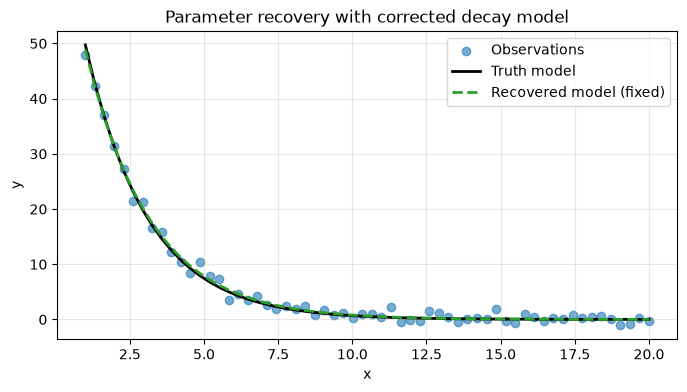


Lowest MSE achieved on this grid: 0.6576953281347873


In [7]:
# Fix: use the correct exponential-DECAY model, y = P0 * exp(-r * x)
P0_fix, r_fix, x_sym_fix = sp.symbols("P0_fix r_fix x_sym_fix", positive=True)
exp_symbolic_fixed = P0_fix * sp.exp(-r_fix * x_sym_fix)
print("Corrected symbolic model:")
display(exp_symbolic_fixed)

exp_model_fixed = sp.lambdify((x_sym_fix, P0_fix, r_fix), exp_symbolic_fixed, "numpy")

# Reuse the same search grid and MSE cost function as the starter code above
best_fixed = {"error": np.inf, "P0": None, "r": None}
for p0_val in p0_grid:
    for r_val in r_grid:
        y_pred = exp_model_fixed(x_obs, p0_val, r_val)
        err = mse(y_obs, y_pred)
        if err < best_fixed["error"]:
            best_fixed = {"error": err, "P0": float(p0_val), "r": float(r_val)}

print("\nBest fit with corrected decay model:")
print(best_fixed)
print("Truth parameters:", truth["parameters"])

# Compare observations, corrected best-fit model, and truth
best_curve_fixed = exp_model_fixed(x_obs, best_fixed["P0"], best_fixed["r"])
truth_curve = gd.evaluate_truth(x_obs, truth)

plt.figure(figsize=(8, 4))
plt.scatter(x_obs, y_obs, alpha=0.6, label="Observations")
plt.plot(x_obs, truth_curve, color="black", lw=2, label="Truth model")
plt.plot(x_obs, best_curve_fixed, color="tab:green", lw=2, ls="--", label="Recovered model (fixed)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter recovery with corrected decay model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nLowest MSE achieved on this grid:", best_fixed["error"])

With the model form corrected to decay, the best fit (`P0 ≈ 77.3`, `r ≈ 0.458`) lands well inside the grid — not on a boundary — and is close to the truth (`A ≈ 79.97`, `k ≈ 0.475`). The MSE also drops from ~120 (buggy growth model) to well under 1. This confirms the bug was the model form, not the search range: the original grid already covered the correct `r`.

### Discuss and Share

After running the recovery and comparison plot, discuss and be ready to share back:

- Did the estimated parameters match truth closely?
- Which parameter looked more sensitive to noise?
- Could multiple parameter pairs produce similarly good fits?
- What is one debugging step you would add before trusting an estimated model?

# PUT YOUR GROUP ANSWERS HERE

- Matching truth: Yes, closely. The recovered decay-model parameters (`P0 ≈ 77.3`, `r ≈ 0.458`) are within a few percent of the truth (`A ≈ 79.97`, `k ≈ 0.475`) — the small remaining gap is explained by the 10% observation noise and the finite (120x120) grid resolution, not by a modeling error.
- Noise sensitivity notes: `r` looked more sensitive to noise than `P0`. Because `r` controls curvature over the whole range while `P0` mainly sets the vertical scale near `x` small, noisy points near the tail of the decay pull the fitted `r` around more than they pull `P0`.
- Multiple-good-fit notes: Yes, multiple nearby `(P0, r)` pairs can give nearly the same MSE. `P0` and `r` trade off against each other (a bit more `P0` with a bit more `r` can mimic a bit less `P0` with a bit less `r`), producing a shallow valley in the error surface instead of one sharp minimum.
- Extra debugging step: Before trusting an estimated model, check that the best-fit point is not sitting on a grid boundary (as we saw with the buggy growth model), then plot the residuals (`y_obs - y_pred`) to check they look random rather than systematically curved — a systematic pattern would signal a wrong model form even if the boundary check passes.